In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
monster = pd.read_csv('../Data/MONSTER.csv').drop(9)

In [3]:
monster.sample(5)

,SEX,AGE,GROUP,CL,FI,PID,OE,HR_PRE,HR_POST
29,1,22,2,11,12,8,12,82,88
8,2,21,1,7,4,9,4,93,80
0,2,19,1,11,7,17,11,72,66
4,1,24,1,12,15,8,11,59,57
38,2,22,3,9,14,10,9,64,89


## Likelihood

In [4]:
from scipy.stats import gamma

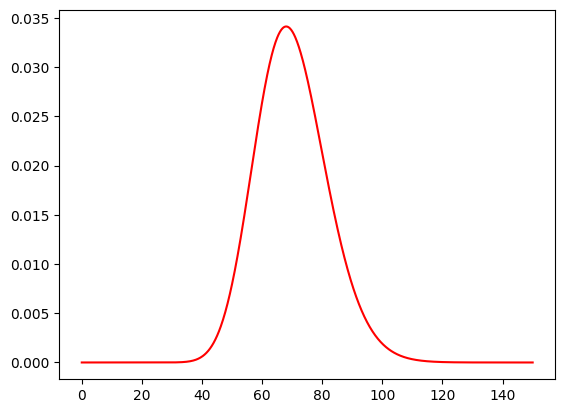

In [5]:
plt.plot(np.linspace(-0,150,1000),gamma.pdf(np.linspace(-0,150,1000), a=35, scale=1/0.5), color='r')

We are going to vary $\beta$. So the possible shapes are:

In [6]:
# betas for plot
np.linspace(0.001, 1, 20)

array([0.001     , 0.05357895, 0.10615789, 0.15873684, 0.21131579,
       0.26389474, 0.31647368, 0.36905263, 0.42163158, 0.47421053,
       0.52678947, 0.57936842, 0.63194737, 0.68452632, 0.73710526,
       0.78968421, 0.84226316, 0.89484211, 0.94742105, 1.        ])

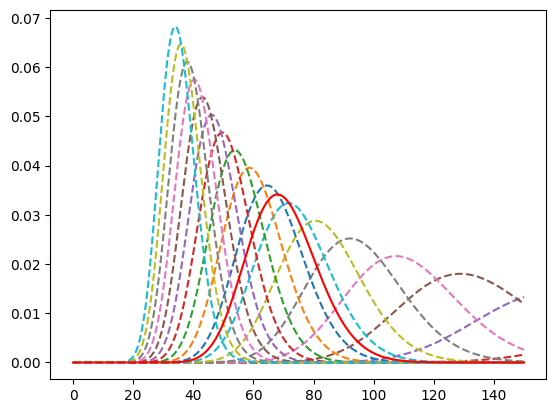

In [7]:
for beta in np.linspace(0.001, 1, 20):
  plt.plot(np.linspace(-0,150,1000),gamma.pdf(np.linspace(-0,150,1000), a=35, scale=1/beta), linestyle='--')

plt.plot(np.linspace(-0,150,1000),gamma.pdf(np.linspace(-0,150,1000), a=35, scale=1/0.5), color='r')
plt.show()

## Prior

The conjugate model for a Gamma likelihood is a Gamma prior for the parameter $\beta$.

Our Gamma-Gamma model is the following:

$$ X \sim Gamma(35, \beta) $$
$$\beta \sim Gamma(?, ?)$$

### Why Gamma, and why these prior parameters?

A note on the modeling choices below — in the original course these were discussed live with students before any data were seen.

**Why a Gamma likelihood for heart rate?** Heart rate is positive and only mildly skewed, so a Normal would also be defensible. We use Gamma here primarily to *demonstrate a different conjugate pair* (Gamma–Gamma) alongside the Beta–Binomial and Normal–Normal pairs covered earlier. Fixing the shape parameter at $\alpha = 35$ leaves a single unknown $\beta$ to update, which keeps the conjugate update simple to write down.

**Why $\alpha_{\text{prior}} = 70,\ \beta_{\text{prior}} = 150$?** The Gamma prior on $\beta$ has prior mean $\alpha_{\text{prior}} / \beta_{\text{prior}} \approx 0.47$. Because $E[X \mid \beta] = \alpha_{\text{lik}} / \beta = 35 / \beta$, this implies a prior expected heart rate around $35 / 0.47 \approx 75$ bpm — a reasonable resting HR for young adults. The relatively concentrated prior reflects that we are not completely uncertain about plausible heart-rate ranges.

**Key point:** these numbers were chosen *before* looking at the data. The whole purpose of a prior is that it encodes belief independent of the dataset at hand. The prior-predictive simulation below is a sanity check that those beliefs are reasonable.

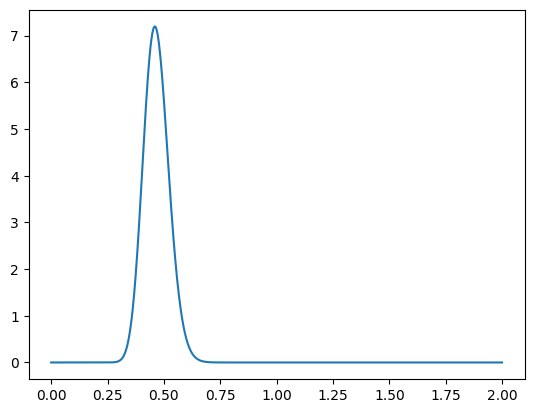

In [8]:
alpha_prior=70 ##### choose prior
beta_prior=150
plt.plot(np.linspace(0,2,1000),gamma.pdf(np.linspace(0,2,1000), a=alpha_prior, scale=1/beta_prior))

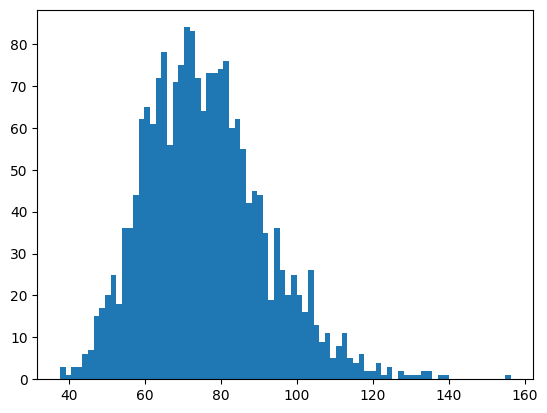

In [9]:
simulated_data = []

for i in range(2000):
  beta = gamma.rvs(a=alpha_prior, scale=1/beta_prior, size=1)[0]
  simulated_data.append(gamma.rvs(a=35, scale=1/beta, size=1)[0])

plt.hist(simulated_data, bins=80)
plt.show()

$$ X \sim Gamma(35, \beta) $$
$$\beta \sim Gamma(70, 150)$$

## Data

In [10]:
prior_alpha = 70
prior_beta = 150

lik_alpha = 35

In [11]:
monster.shape[0]

44

In [12]:
np.sum(monster.HR_PRE)

np.int64(3305)

In [13]:
post_alpha = prior_alpha + monster.shape[0] * lik_alpha
post_beta = prior_beta + np.sum(monster.HR_PRE)

In [14]:
print(post_alpha, post_beta)

1610 3455


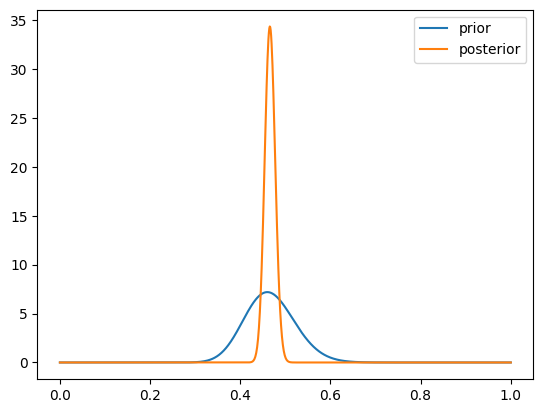

In [15]:
plt.plot(np.linspace(0,1,1000),gamma.pdf(np.linspace(0,1,1000), a=prior_alpha, scale=1/prior_beta), label='prior')
plt.plot(np.linspace(0,1,1000),gamma.pdf(np.linspace(0,1,1000), a=post_alpha, scale=1/post_beta), label='posterior')

plt.legend()
plt.show()

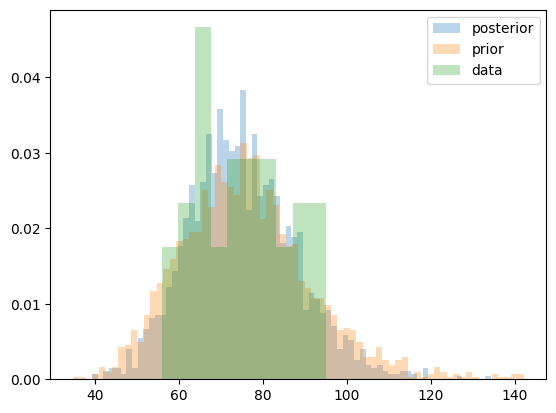

In [16]:
simulated_post = []

for i in range(2000):
  beta = gamma.rvs(a=post_alpha, scale=1/post_beta, size=1)[0]
  simulated_post.append(gamma.rvs(a=35, scale=1/beta, size=1)[0])


simulated_prior = []

for i in range(2000):
  beta = gamma.rvs(a=alpha_prior, scale=1/beta_prior, size=1)[0]
  simulated_prior.append(gamma.rvs(a=35, scale=1/beta, size=1)[0])

plt.hist(simulated_post, bins=70, density=True, alpha=0.3, label='posterior')
plt.hist(simulated_prior, bins=70, density=True, alpha=0.3, label='prior')
plt.hist(monster.HR_PRE, bins=10, density=True, alpha=0.3, label='data')
plt.legend()
plt.show()

#### Mean

$$E[Gamma] = \frac{\alpha}{\beta}$$

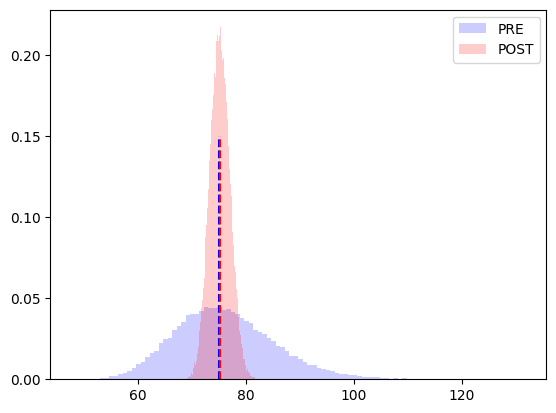

In [17]:
# distribution of the mean
plt.hist(35 / gamma.rvs(a=prior_alpha, scale=1/prior_beta, size=50000),bins=100, alpha=0.2, label='PRE', color='b', density=True)
plt.vlines(x=35 / gamma.mean(a=prior_alpha, scale=1/prior_beta), ymin=0, ymax=0.15, color='b', linestyles='--')
plt.hist(35 / gamma.rvs(a=post_alpha, scale=1/post_beta, size=50000),bins=100, alpha=0.2, label='POST', color='r', density=True)
plt.vlines(x=35 / gamma.mean(a=post_alpha, scale=1/post_beta), ymin=0, ymax=0.15, color='r', linestyles='--')
plt.legend()
plt.show()

# Groups

In [18]:
experimental = monster.query('GROUP == 1')

In [19]:
experimental

,SEX,AGE,GROUP,CL,FI,PID,OE,HR_PRE,HR_POST
0,2,19,1,11,7,17,11,72,66
1,1,22,1,12,6,14,7,56,55
2,2,22,1,11,4,16,7,87,89
3,2,22,1,8,3,13,9,91,80
4,1,24,1,12,15,8,11,59,57
5,2,21,1,12,7,10,8,79,66
6,1,22,1,11,8,8,7,67,94
7,2,21,1,10,12,12,14,78,103
8,2,21,1,7,4,9,4,93,80
10,1,24,1,8,7,7,7,94,95


In [20]:
post_alpha_before = prior_alpha + experimental.shape[0] * lik_alpha
post_beta_before = prior_beta + np.sum(experimental.HR_PRE)

post_alpha_after = prior_alpha + experimental.shape[0] * lik_alpha
post_beta_after = prior_beta + np.sum(experimental.HR_POST)

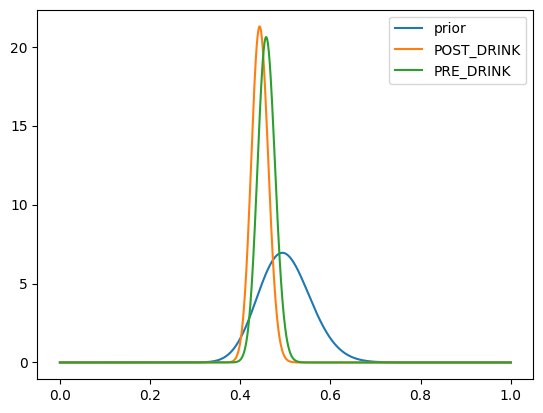

In [21]:
plt.plot(np.linspace(0,1,1000),gamma.pdf(np.linspace(0,1,1000), a=75, scale=1/150), label='prior')
plt.plot(np.linspace(0,1,1000),gamma.pdf(np.linspace(0,1,1000), a=post_alpha_after, scale=1/post_beta_after), label='POST_DRINK')
plt.plot(np.linspace(0,1,1000),gamma.pdf(np.linspace(0,1,1000), a=post_alpha_before, scale=1/post_beta_before), label='PRE_DRINK')

plt.legend()
plt.show()

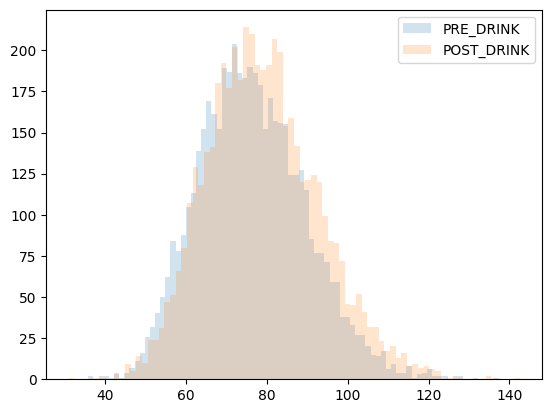

In [22]:
simulated_pre = []
simulated_post = []

for i in range(5000):
  beta = gamma.rvs(a=post_alpha_before, scale=1/post_beta_before, size=1)[0]
  simulated_pre.append(gamma.rvs(a=35, scale=1/beta, size=1)[0])

  beta = gamma.rvs(a=post_alpha_after, scale=1/post_beta_after, size=1)[0]
  simulated_post.append(gamma.rvs(a=35, scale=1/beta, size=1)[0])

plt.hist(simulated_pre, bins=80, label='PRE_DRINK', alpha=0.2)
plt.hist(simulated_post, bins=80, label='POST_DRINK', alpha=0.2)
plt.legend()
plt.show()

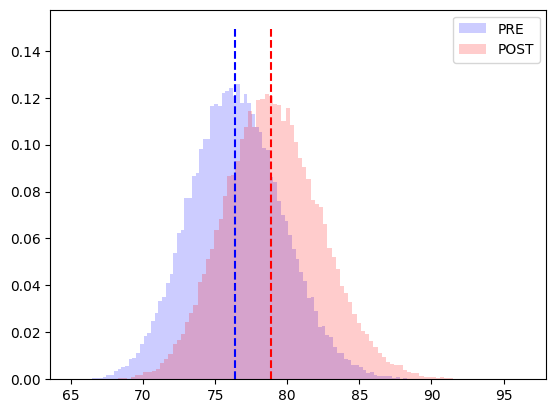

In [23]:
# distribution of the mean
plt.hist(35 / gamma.rvs(a=post_alpha_before, scale=1/post_beta_before, size=50000),bins=100, alpha=0.2, label='PRE', color='b', density=True)
plt.vlines(x=35 / gamma.mean(a=post_alpha_before, scale=1/post_beta_before), ymin=0, ymax=0.15, color='b', linestyles='--')
plt.hist(35 / gamma.rvs(a=post_alpha_after, scale=1/post_beta_after, size=50000),bins=100, alpha=0.2, label='POST', color='r', density=True)
plt.vlines(x=35 / gamma.mean(a=post_alpha_after, scale=1/post_beta_after), ymin=0, ymax=0.15, color='r', linestyles='--')
plt.legend()
plt.show()

## Modeling Differences

In [24]:
differences = experimental.HR_POST - experimental.HR_PRE
differences

0     -6
1     -1
2      2
3    -11
4     -2
5    -13
6     27
7     25
8    -13
10     1
11    -7
12   -14
13    23
14    29
dtype: int64

In [25]:
from scipy.stats import norm

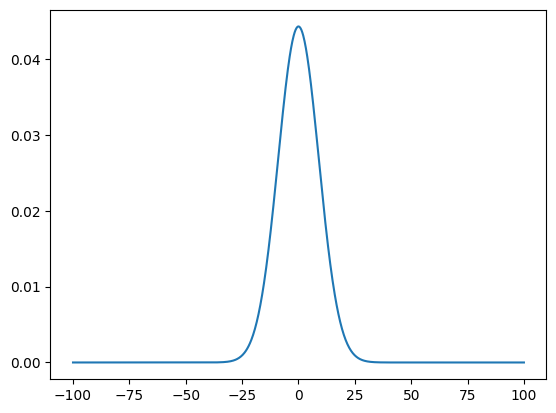

In [26]:
sd_lik = 9

d = np.linspace(-100,100,1000)
plt.plot(d, norm.pdf(d, loc=0, scale=sd_lik))
plt.show()

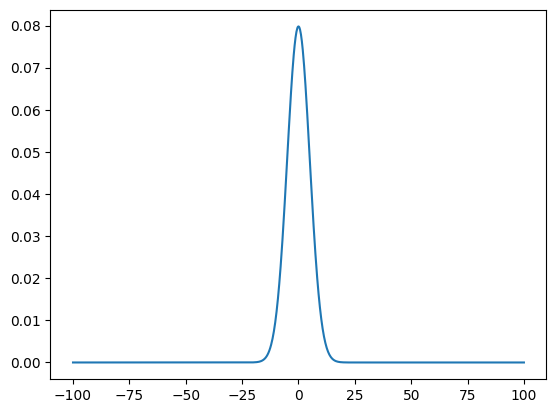

In [27]:
sd_prior = 5
mu_prior = 0

d = np.linspace(-100,100,1000)
plt.plot(d, norm.pdf(d, loc=mu_prior, scale=sd_prior))
plt.show()

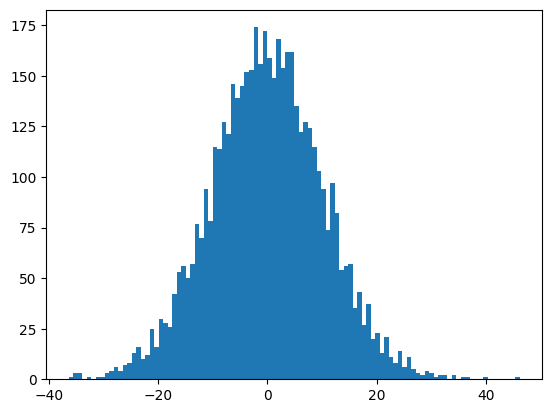

In [28]:
diff_data = []

for i in range(5000):
  mu_data = norm.rvs(loc=mu_prior, scale=sd_prior, size=1)[0]
  diff_data.append(norm.rvs(loc=mu_data, scale=sd_lik, size=1)[0])

plt.hist(diff_data, bins=100)
plt.show()

In [29]:
mu_post = (
    1/(1/(sd_prior**2) + experimental.shape[0]/(sd_lik**2)) *
    (mu_prior/(sd_prior**2) + np.sum(differences)/(sd_lik**2))
)
sd_post = np.sqrt(
    1/(1/(sd_prior**2) + experimental.shape[0]/(sd_lik**2))
)

In [30]:
mu_post

np.float64(2.3201856148491875)

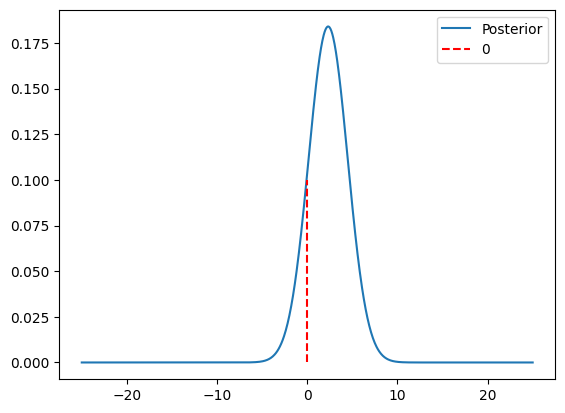

In [31]:
d = np.linspace(-25,25,1000)
plt.plot(d, norm.pdf(d, loc=mu_post, scale=sd_post),label='Posterior')
plt.vlines(0, ymin=0, ymax=0.1, color='r', linestyles='--', label='0')
plt.legend()
plt.show()

In [32]:
norm.cdf(0, loc=mu_post, scale=sd_post)

np.float64(0.14221812446929494)

In [33]:
1-norm.cdf(0, loc=mu_post, scale=sd_post)

np.float64(0.8577818755307051)

What is the probability that the drink's effect on the pulse is positive?

In [34]:
1-norm.cdf(0, loc=mu_post, scale=sd_post)

np.float64(0.8577818755307051)

In [35]:
diff_control = monster.query('GROUP == 2').HR_POST - monster.query('GROUP == 2').HR_PRE
diff_control

15    11
16    24
17    26
18    -2
19    -5
20    -7
21    -4
22    -2
23   -11
24    -6
25     0
26    18
27    -2
28    12
29     6
dtype: int64

In [36]:
mu_post_control = (
    1/(1/(sd_prior**2) + len(diff_control)/(sd_lik**2)) *
    (mu_prior/(sd_prior**2) + np.sum(diff_control)/(sd_lik**2))
)
sd_post_control = np.sqrt(
    1/(1/(sd_prior**2) + len(diff_control)/(sd_lik**2))
)

In [37]:
diff_placebo = monster.query('GROUP == 3').HR_POST - monster.query('GROUP == 3').HR_PRE
diff_placebo

30     7
31    -8
32     4
33    -9
34    -8
35   -15
36    19
37   -11
38    25
39    12
40    -2
41    -9
42    -8
43    11
44    -6
dtype: int64

In [38]:
mu_post_placebo = (
    1/(1/(sd_prior**2) + len(diff_placebo)/(sd_lik**2)) *
    (mu_prior/(sd_prior**2) + np.sum(diff_placebo)/(sd_lik**2))
)
sd_post_placebo = np.sqrt(
    1/(1/(sd_prior**2) + len(diff_placebo)/(sd_lik**2))
)

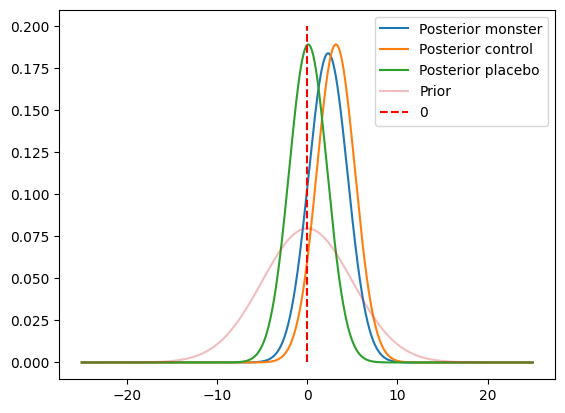

In [39]:
d = np.linspace(-25,25,1000)
plt.plot(d, norm.pdf(d, loc=mu_post, scale=sd_post),
         label='Posterior monster')
plt.plot(d, norm.pdf(d, loc=mu_post_control, scale=sd_post_control),
         label='Posterior control')
plt.plot(d, norm.pdf(d, loc=mu_post_placebo, scale=sd_post_placebo),
         label='Posterior placebo')
plt.plot(d, norm.pdf(d, loc=mu_prior, scale=sd_prior),
         label='Prior', alpha=0.3)

plt.vlines(0, ymin=0, ymax=0.2, color='r', linestyles='--', label='0')
plt.legend()
plt.show()